# Temporal · single-field — **sim vs theory** reference

The same **load → run → plot** core as [`template_temporal_single.ipynb`](template_temporal_single.ipynb), with a matched simulator overlaid.  The only addition over the plain template is section 3 (the simulator) and passing its result to `nb.plot_cumulant(..., sim=...)`.

Every `*_sim_compare` notebook in [`../temporal/`](../temporal) and [`../spatial/`](../spatial) follows this shape: the theory side is `nb_support`; only the simulator differs per model.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import nb_support as nb
# simulator + cumulant estimator for THIS model
from models.ou_langevin_sim_numba import sim_ou_quartic_numba
from models.cumulant_estimator import compute_kpoint_slice
print('nb_support \u2192', nb.REPO_ROOT)

nb_support → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Theory side (identical to the plain template)

Load the theory from its file, set one `nb.Config`, run.

In [2]:
THEORY = 'ou_quartic_double_well'

cfg = nb.Config(
    k=2,                # any k: 2 = C(τ); 3+ = k-point slice C_k(τ)
    max_ell=1,          # tree + 1-loop
    tau_max=8.0,
    tau_step=0.5,
    show_orders='cumulative',
)

model, mod = nb.load_theory(THEORY)
res = nb.run(model, cfg, mod)
print(nb.summary(res))

theory : 'OU Quartic Double Well'
k      : 2    max_ell : 1
fields : ['dx']   spatial_dim : 0


## 3. Simulation side (matched parameters, any k)

Pull the exact parameters and τ-grid the theory used out of the result (`res['_resolved']['fundamental']`, `res['tau_grid']`, the mean-field saddle `res['mf']`), run a few Euler–Maruyama trajectories, and estimate the **k-point slice** `C_k(τ)` with `compute_kpoint_slice` (one swept leg, the rest pinned at τ=0 — matching the theory slice).  The output is a plain `{tau, C, C_err}` dict for every k.

In [3]:
fund = res['_resolved']['fundamental']
mu, eps, D = float(fund['mu']), float(fund['eps']), float(fund['D'])
x_init = float(res['mf']['x'][0])      # expand around the MF saddle
K = int(cfg.k)

# --- simulation knobs (kept small so this runs in seconds) ---
N_RUNS = 4
T_sim  = float(5e5)
dt_sim = 0.05
dt_bin = 0.5
tau_max = float(cfg.tau_max)

n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)
tau_sim_grid   = np.arange(-max_lag_bins, max_lag_bins + 1) * dt_bin_eff

# k-generic k-point slice C_k(τ) = ⟨φ(0) φ(τ) φ(0) … φ(0)⟩_c: leg 1 is
# swept, legs 0 and 2..k-1 are pinned at τ=0 — the SAME slice the theory
# stores in res['C_tau'] (nb.run synthesises it from total_C for k≥3).
lag_bins    = [0, None] + [0] * (K - 2)
field_types = ['dv'] * K
pop_indices = [0] * K

_ = sim_ou_quartic_numba(int(1000), float(dt_sim), mu, eps, D, x_init,
                         int(bin_size_steps), int(100), int(0))  # JIT

C_runs, var_runs, mean_runs = [], [], []
t0 = time.perf_counter()
for run in range(N_RUNS):
    x_bins = sim_ou_quartic_numba(
        int(n_steps), float(dt_sim), mu, eps, D, x_init,
        int(bin_size_steps), int(n_bins), int(1234 + run))
    var_runs.append(float((x_bins**2).mean()))
    mean_runs.append(float(x_bins.mean()))
    _, C_run = compute_kpoint_slice(
        binned_counts=np.zeros_like(x_bins), dt_bin=float(dt_bin_eff),
        pop_indices=pop_indices, lag_bins=lag_bins,
        max_lag_bins=int(max_lag_bins), field_types=field_types,
        voltage_bins=x_bins)
    C_runs.append(np.asarray(C_run).real)

C_runs = np.array(C_runs)
sim = {'tau': tau_sim_grid, 'C': C_runs.mean(axis=0),
       'C_err': C_runs.std(axis=0, ddof=1) / np.sqrt(N_RUNS)}
_mid = len(sim['C']) // 2
_i0  = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
print(f'sim: {N_RUNS} runs x T={T_sim:.0g} in {time.perf_counter()-t0:.1f}s   (k={K}, {K}-point slice)')
print(f'  <x>   = {np.mean(mean_runs):+.4f}    <x^2> = {np.mean(var_runs):.4f}')
print(f'  sim    C{K}(0) = {sim["C"][_mid]:+.5f}  (bin-averaged, dt_bin={float(dt_bin):.2f})')
print(f'  theory C{K}(0) = {float(np.real(res["C_tau"])[_i0]):+.5f}  (tree + {cfg.max_ell}-loop)')
if K >= 3 and abs(float(np.real(res['C_tau'])[_i0])) < 1e-9:
    print('  (κ_k = 0 here: odd cumulants vanish at the symmetric saddle x*=0 —')
    print('   use fundamental={"mu": -1.0, ...} + Config.fixed_point_index to sit in one well)')

sim: 4 runs x T=5e+05 in 1.3s   (k=2, 2-point slice)
  <x>   = -0.0002    <x^2> = 0.6873
  sim    C2(0) = +0.68728  (bin-averaged, dt_bin=0.50)
  theory C2(0) = +0.70000  (tree + 1-loop)


## 4. Theory vs simulation

`nb.plot_cumulant` overlays the simulated k-point slice on the theory curve for **any k**.  For k=2 this is the usual `C(τ)`; for k≥3 it is the 1-D slice `C_k(τ) = ⟨φ(0) φ(τ) φ(0)…⟩_c` (leg 1 swept, the rest pinned at τ=0) — `nb.run` synthesises the matching theory slice from `res['total_C']`, and the simulator estimates it with `compute_kpoint_slice`.  `cfg.show_orders` controls the per-loop-order theory overlay.

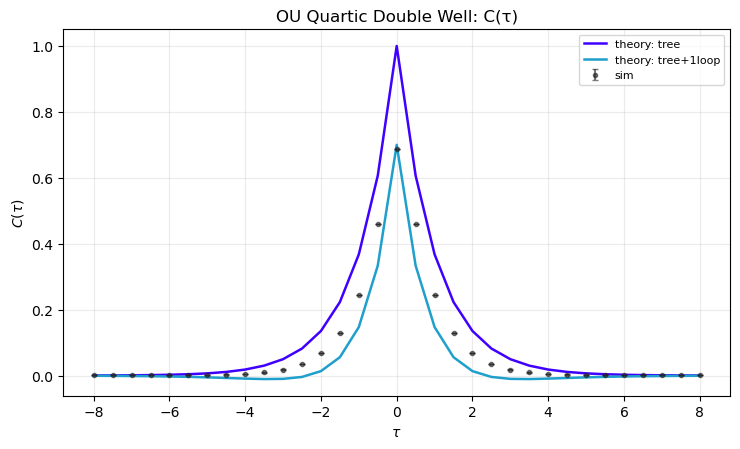

In [4]:
fig = nb.plot_cumulant(res, cfg, model, sim=sim)
plt.show()